# Explore the ERA5 Dataset with Python

intinya, tetep aja harus request data -> gak readily available. Jadi datanya harus distore somewhere. 

In [1]:
import cdsapi
import earthkit.data as ekd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr 

In [2]:
variables = [
        "mean_wave_direction",
        "significant_height_of_combined_wind_waves_and_swell",
        "peak_wave_period"
    ]

areas = np.array([
        [  59.2, -141.7,   58.8, -141.3],
        [  38.2, -124.2,   37.8, -123.8],
        [  40.7,  -71.2,   40.3,  -70.8],
        [  53.2,  -11.2,   52.8,  -10.8],
        [  41.7,  142.8,   41.3,  143.2],
        [  13.2,  -92.7,   12.8,  -92.3],
        [  25.2,  -96.7,   24.8,  -96.3],
        [  36.7,   13.8,   36.3,   14.2],
        [   6.7,  -52.7,    6.3,  -52.3],
        [   5.7,  -12.2,    5.3,  -11.8],
        [  19.7,   58.8,   19.3,   59.2],
        [  21.2,   89.3,   20.8,   89.7],
        [  28.2,  127.3,   27.8,  127.7],
        [ -21.3,  -71.7,  -21.7,  -71.3],
        [ -23.8,  -41.7,  -24.2,  -41.3],
        [ -10.8,   12.8,  -11.2,   13.2],
        [  -2.8,   40.8,   -3.2,   41.2],
        [  -4.8,  100.8,   -5.2,  101.2],
        [  -1.8,  141.3,   -2.2,  141.7],
        [ -53.8,  -75.2,  -54.2,  -74.8],
        [ -35.3,   17.8,  -35.7,   18.2],
        [ -34.8,  113.8,  -35.2,  114.2],
        [ -31.3,  153.3,  -31.7,  153.7],
        [ -44.3,  172.3,  -44.7,  172.7]
    ])

priorities = [2, 6, 10, 17, 19, 22]
priority_areas = areas[priorities,:]

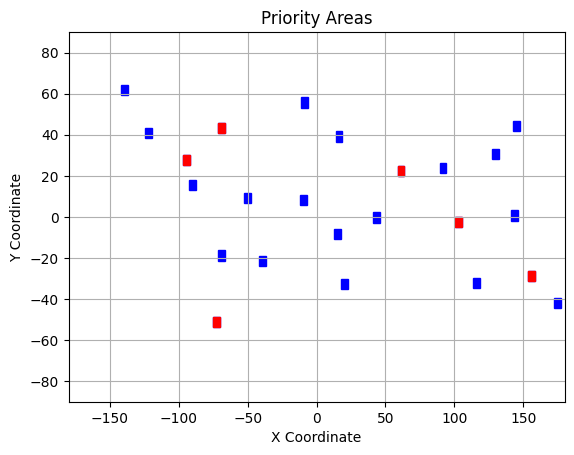

In [3]:
import matplotlib.pyplot as plt

# Function to plot a rectangle at (ox, oy)
def plot_rect(ox, oy, ax, color_sel='None'):
    rect = plt.Rectangle((ox, oy), 5, 5, linewidth=1, edgecolor=color_sel, facecolor=color_sel)  # Customize color if needed
    ax.add_patch(rect)


fig, axs = plt.subplots(1, 1)

# Loop through priority areas and plot rectangles
for o in areas:
    plot_rect(o[1], o[0], axs, 'b')

# Loop through priority areas and plot rectangles
for o in priority_areas:
    plot_rect(o[1], o[0], axs, 'r')

# Optional: setting axis limits to fit all rectangles
axs.set_xlim(-180, 180)
axs.set_ylim(-90, 90)

# Adding grid and labels for clarity
axs.grid(True)
axs.set_title('Priority Areas')
axs.set_xlabel('X Coordinate')
axs.set_ylabel('Y Coordinate')

# Show the plot
plt.show()

In [4]:
variables

['mean_wave_direction',
 'significant_height_of_combined_wind_waves_and_swell',
 'peak_wave_period']

In [ ]:
dataset = "reanalysis-era5-single-levels"
client = cdsapi.Client()

priorities = [2, 6, 10, 17, 19, 22]
nonpriorities = [0, 1, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 18, 21, 23]
sandy = [1, 2, 4, 5, 6, 7, 9, 10, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
sandy_priorities = [2, 6, 10, 17, 19, 22]
sandy_nonpriorities = [1, 4, 5, 7, 9, 13, 14, 15, 16, 20, 21, 23]

for i in sandy_nonpriorities[3:]:
    for year in range(1979, 2020, 4):
        request = {
            "product_type": ["reanalysis"],
            "variable": ['significant_height_of_combined_wind_waves_and_swell'],
            "year": [str(year), str(year+1), str(year+2), str(year+3)],
            "month": [
                "01", "02", "03",
                "04", "05", "06",
                "07", "08", "09",
                "10", "11", "12"
            ],
            "day": [
                "01", "02", "03",
                "04", "05", "06",
                "07", "08", "09",
                "10", "11", "12",
                "13", "14", "15",
                "16", "17", "18",
                "19", "20", "21",
                "22", "23", "24",
                "25", "26", "27",
                "28", "29", "30",
                "31"
            ],
            "time": [
                "00:00", "01:00", "02:00",
                "03:00", "04:00", "05:00",
                "06:00", "07:00", "08:00",
                "09:00", "10:00", "11:00",
                "12:00", "13:00", "14:00",
                "15:00", "16:00", "17:00",
                "18:00", "19:00", "20:00",
                "21:00", "22:00", "23:00",
            ],
            "area": areas[i].tolist(),
            "data_format": "grib",
            "download_format": "unarchived"
        }

        target = f'../data/ERA5/p{i+1}_{year}_{year+3}.grib'
        client.retrieve(dataset, request, target)


2025-12-17 14:44:45,594 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-12-17 14:44:45,953 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2025-12-17 14:44:45,954 INFO Request ID is 6093aaa0-2693-4a4d-8e45-c40b69f3092f
2025-12-17 14:44:46,027 INFO status has been updated to accepted
2025-12-17 14:45:07,192 INFO status has been updated to running
2025-12-17 15:11:12,394 INFO status has been updated to successful
2025-12-17 15:11:16,631 INFO [2

In [ ]:
ds = xr.load_dataarray('data/ERA5/p20_1989.grib', engine='cfgrib')
ds = ds.squeeze()

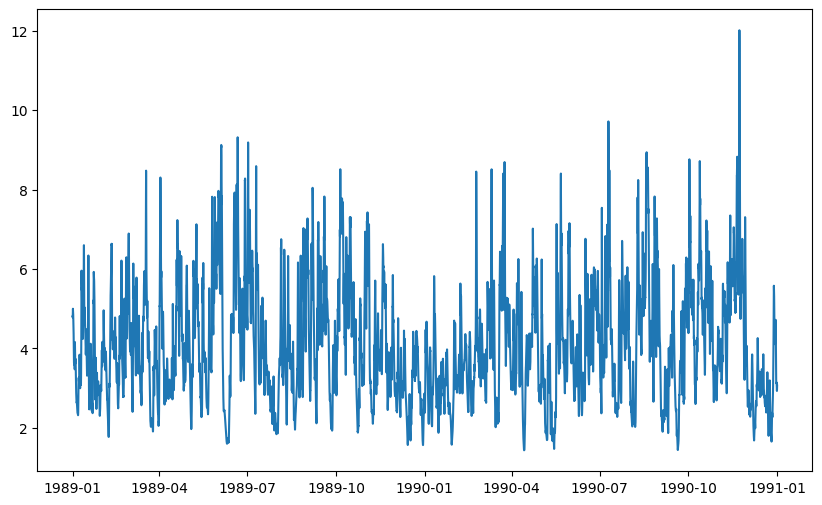

In [30]:
plt.figure(figsize=(10,6))
plt.plot(ds.time.values, ds.values)

In [31]:
import os
from glob import glob

In [53]:
# Define the directory and the file pattern (e.g., p20_*.grb)
input_dir = 'data/ERA5/'
file_pattern = 'p3_*.grib'

files = glob(os.path.join(input_dir, file_pattern))

datasets = [
    xr.open_dataset(f, engine='cfgrib')  # or with options, see below
    for f in files
]

ds = xr.concat(dataset, dim='time')

Ignoring index file 'data/ERA5\\p3_1979.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1980.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1981.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1982.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1983.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1984.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1985.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1986.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1987.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1988.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1989.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'data/ERA5\\p3_1990.grib.5b7b6.idx' incompatible with GR

NameError: name 'dataset' is not defined

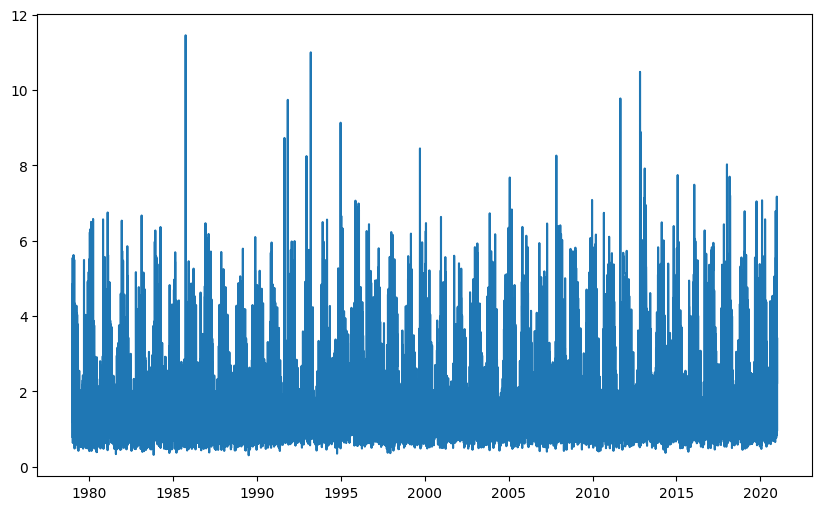

In [52]:
hs = ds.squeeze().swh.values
time = ds.time.values

plt.figure(figsize=(10,6))
plt.plot(time, hs)

## Time series dataset
ERA5 have a dedicated catalogue entry, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way)

However, the retrieved .nc file can't be opened. The dataset is still experimental.  
More info: [ERA5 hourly time-series data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)

In [ ]:
poi = gpd.read_file('data/point_of_interest.json')

lon = poi.iloc[4].geometry.x
lat = poi.iloc[4].geometry.y
print(lon, lat)

In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels-timeseries"
client = cdsapi.Client()

request = {
    "variable": [
        "significant_height_of_combined_wind_waves_and_swell"
    ],
    "location": {"longitude": lon, "latitude": lat},
    "date": ["1979-01-01/2020-12-31"],
    "data_format": "netcdf"
}

target = f'data/ERA5/ts/p5_test.nc'
client.retrieve(dataset, request, target)
